# ADeLe Practical Session: Build a Better Assessor

Welcome! In this practical you'll be leverage the content you've learned in the lecture yesterday to build meta-models that can well explain and predict model behavior. More specifically, in this notebook, you will work with the **ADeLe battery** ([Zhou et al., Nature 2026](https://arxiv.org/abs/2503.06378)) — a dataset where every benchmark instance has been annotated along 18 cognitive *demand* dimensions, plus an *unguessability* score. For each of 15 LLMs, we also have the model's verification label (right / wrong) on every instance.

**Your goal:** train a per-LLM **assessor** that predicts whether the LLM will succeed on a given instance, and then **improve it** beyond what the paper reports — either by engineering richer input features or by changing the model architecture or any other creative solutions. We evaluate predictive power both **in-distribution** (held-out instances) and **out-of-distribution** (held-out benchmarks or tasks).

References: [paper](https://www.nature.com/articles/s41586-026-10303-2) · [project page](https://kinds-of-intelligence-cfi.github.io/ADELE/) ·
The assessor is trained **per LLM** (one model per subject). The target is the binary column `verification_final` — 1 if the LLM got that instance right, 0 otherwise.

**Two Colab tips before you start:**

- To save your edits, use *File → Save a copy in Drive* (or *Save a copy in GitHub*). When the notebook is opened directly from GitHub it's read-only.
- Free Colab runtimes idle out after ~90 min of inactivity. If yours dies mid-session, just re-run the cells from the top — the full notebook completes in under a minute.

## 1. Setup

We shallow-clone a small classroom repo containing the `o1_re=low` subject CSV and the ADeLe rubric files. No extra `pip install` needed — `pandas`, `numpy`, `scikit-learn`, and `matplotlib` ship with Colab.

In [1]:
import os
from pathlib import Path

REPO_URL = "https://github.com/lexzhou/ADeLe-practical-session.git"
REPO_DIR = Path("ADeLe-practical-session")

if not REPO_DIR.exists():
    !git clone --depth 1 $REPO_URL
else:
    print(f"{REPO_DIR} already present — skipping clone.")

DATA_DIR    = REPO_DIR
RUBRICS_DIR = REPO_DIR / "rubrics"

csvs = sorted(DATA_DIR.glob("*.csv"))
print(f"\nRepo root: {REPO_DIR}")
print(f"CSV file(s): {[p.name for p in csvs]}")
print(f"Rubrics: {len(list(RUBRICS_DIR.glob('*.txt')))} rubric .txt files")

Cloning into 'ADeLe-practical-session'...
remote: Enumerating objects: 26, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 26 (delta 0), reused 23 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (26/26), 9.98 MiB | 5.46 MiB/s, done.

Repo root: ADeLe-practical-session
CSV file(s): ['o1_re=low.csv']
Rubrics: 19 rubric .txt files


## 2. Data exploration

We focus on a single LLM — **OpenAI o1** (`o1_re=low`, `reasoning_effort=low`), one of the subjects where we got the lowest OOD predictive power in the ADeLe paper. The CSV is fully self-contained: same set of instances as every other subject in the ADeLe battery, but the verification label and the model's response are subject-specific.

A note on the choice of subject: `o1_re=low` is right on ~84% of instances, the highest of the 15 LLMs in the ADeLe paper. That means the assessor's challenge is mostly **predicting the ~16% of failures** — a class-imbalanced regime where naive accuracy is uninformative and calibration matters.

In [2]:
import pandas as pd
import numpy as np

SUBJECTS = ['o1_re=low']  # single subject; the list/dict shape stays so you can extend later.

# The 19 ADeLe features used in the paper's baseline assessor:
# UG (Unguessability) + 18 cognitive / knowledge / metacognitive demand dimensions.
DEMAND_COLS = [
    'UG',                              # Unguessability
    'AS',                              # Attention & Scan
    'CEc', 'CEe',                      # Causal Explanation (counterfactual / evidential)
    'CL',                              # Concept Learning
    'KNn', 'KNa', 'KNc', 'KNf', 'KNs', # Knowledge (novelty / access / construction / facts / specialisation)
    'MCt', 'MCu', 'MCr',               # Metacognition (transfer / updating / reflection)
    'MS',                              # Memory Search
    'QLq', 'QLl',                      # Quantitative Logic (complex / linear)
    'SNs',                             # Symbolic Notation Syntax
    'VO',                              # Visualisation & Organisation
    'AT',                              # Adaptive Thinking
]

dfs = {s: pd.read_csv(DATA_DIR / f'{s}.csv') for s in SUBJECTS}

print(f"{'subject':25s}  {'rows':>6s}  {'accuracy':>9s}")
for s, df in dfs.items():
    print(f"{s:25s}  {len(df):>6d}  {df['verification_final'].mean():>9.3f}")

subject                      rows   accuracy
o1_re=low                   16108      0.843


In [3]:
# Full column list. Note: many useful columns beyond the 19 demand
# dims live here — you'll want to mine them for new features in Section 4.
sample_df = dfs['o1_re=low']
print(f"All {len(sample_df.columns)} columns in o1_re=low.csv:\n")
for c in sample_df.columns:
    flag = '  <-- in DEMAND_COLS' if c in DEMAND_COLS else ''
    print(f"  {c}{flag}")

All 39 columns in o1_re=low.csv:

  source
  benchmark
  task
  answer_format
  instance_id
  original_id
  question
  prompt
  groundtruth
  bench+task
  response_o1_re=low
  response_o1_re=low_tokens
  verification_gpt4o
  verification_claude
  BQ_RA_accuracy
  BQ_RA_objectivity
  BQ_RA_ambiguity
  BQ_RA_timesensitivity
  BQ_answer_format_detail
  UG  <-- in DEMAND_COLS
  AS  <-- in DEMAND_COLS
  CEc  <-- in DEMAND_COLS
  CEe  <-- in DEMAND_COLS
  CL  <-- in DEMAND_COLS
  KNn  <-- in DEMAND_COLS
  KNa  <-- in DEMAND_COLS
  KNc  <-- in DEMAND_COLS
  KNf  <-- in DEMAND_COLS
  KNs  <-- in DEMAND_COLS
  MCt  <-- in DEMAND_COLS
  MCu  <-- in DEMAND_COLS
  MCr  <-- in DEMAND_COLS
  MS  <-- in DEMAND_COLS
  QLq  <-- in DEMAND_COLS
  QLl  <-- in DEMAND_COLS
  SNs  <-- in DEMAND_COLS
  VO  <-- in DEMAND_COLS
  AT  <-- in DEMAND_COLS
  verification_final


In [4]:
# Each demand dimension has a rubric defining what levels 0..5 mean.
# Here's the rubric for AS (Attention & Scan) as an example.
print((RUBRICS_DIR / 'AS.txt').read_text())

This criterion assesses the level of attention and scan required to focus on or locate specific elements within a given stream of information or environment in the whole process of solving a task. During this process, there is the need to actively scan for or retrieve elements that meet predetermined criteria. The level represents the extent to which the task requires locating and focusing on specific target information, ranging from situations where the target is immediately obvious to those requiring sustained tracking of multiple targets among numerous distractors—any elements that are irrelevant to solve the task, such as visual objects, sounds, pieces of text, noise, or other stimuli, but compete for attention with the target information—in complex, dynamic environments. The challenge is not on determining what to look for but focusing the attention to find it within a larger context. This differs from tasks where there's a need to identify which pieces of information are relevant

## 3. Baseline assessor (paper reproduction)

The paper's baseline is a **Random Forest** trained per LLM on the 19 ADeLe features. We evaluate three settings:

- **ID** (in-distribution): standard 10-fold CV at the instance level.
- **OOD by task**: 10-fold CV where folds are *task* groups (a task held out during training is unseen at test time).
- **OOD by benchmark**: same, but folds are *benchmarks* — the hardest split, since the held-out benchmark may differ in style, format, and demand profile from everything in training.

Metrics: **AUROC** (discrimination) and **ECE** (calibration). We also report subject accuracy as the trivial baseline a constant predictor would hit.

In [5]:
import time
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score


def calculate_ece(y_true, y_pred, n_bins=10):
    """Expected Calibration Error: bin-frequency-weighted mean |acc − conf|."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_idx = np.minimum(np.digitize(y_pred, bin_edges) - 1, n_bins - 1)
    ece, n = 0.0, len(y_true)
    for i in range(n_bins):
        mask = bin_idx == i
        k = int(mask.sum())
        if k > 0:
            ece += (k / n) * abs(y_true[mask].mean() - y_pred[mask].mean())
    return ece


def default_rf(seed):
    """The paper's Random Forest config."""
    return RandomForestClassifier(random_state=seed, min_samples_split=50, criterion='entropy')


def kfold_evaluate(X, y, groups=None, model_factory=default_rf, n_splits=10, seed=42):
    """
    Generic 10-fold evaluator.
      groups=None              -> ID  (KFold over rows)
      groups=<pd.Series>       -> OOD (KFold over unique group values; held-out group rows = test set)
    Returns dict with AUROC, accuracy, ECE.
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    all_true, all_proba, all_pred = [], [], []

    if groups is None:
        for tr, te in kf.split(X):
            m = model_factory(seed).fit(X.iloc[tr], y.iloc[tr])
            p = m.predict_proba(X.iloc[te])[:, 1]
            all_true.extend(y.iloc[te]); all_proba.extend(p); all_pred.extend((p > 0.5).astype(int))
    else:
        unique_vals = np.array(sorted(groups.unique()))
        rng = np.random.default_rng(seed)
        rng.shuffle(unique_vals)
        for _, te_v_idx in kf.split(unique_vals):
            te_vals = set(unique_vals[te_v_idx])
            te_mask = groups.isin(te_vals).values
            tr_mask = ~te_mask
            m = model_factory(seed).fit(X[tr_mask], y[tr_mask])
            p = m.predict_proba(X[te_mask])[:, 1]
            all_true.extend(y[te_mask]); all_proba.extend(p); all_pred.extend((p > 0.5).astype(int))

    return {
        'AUROC':    roc_auc_score(all_true, all_proba),
        'accuracy': accuracy_score(all_true, all_pred),
        'ECE':      calculate_ece(all_true, all_proba),
    }

In [6]:
def baseline_features(df):
    """The paper's 19 ADeLe features. Numeric, NaN-tolerant."""
    return df[DEMAND_COLS].apply(pd.to_numeric, errors='coerce')


def evaluate_subject(df, feature_builder, model_factory=default_rf, seed=42):
    """Run ID + OOD-task + OOD-benchmark for one subject. Returns a flat dict."""
    X = feature_builder(df)
    y = df['verification_final']
    keep = ~X.isna().any(axis=1)
    X = X[keep].reset_index(drop=True)
    y = y[keep].reset_index(drop=True)
    df = df[keep].reset_index(drop=True)

    out = {'accuracy': float(y.mean())}
    for label, groups in [('ID', None), ('OOD_task', df['task']), ('OOD_benchmark', df['benchmark'])]:
        r = kfold_evaluate(X, y, groups=groups, model_factory=model_factory, seed=seed)
        out[f'AUROC_{label}'] = r['AUROC']
        out[f'ECE_{label}']   = r['ECE']
    return out


def evaluate_all(feature_builder, model_factory=default_rf, subjects=SUBJECTS, seed=42, verbose=True):
    """Build the comparison table across all subjects."""
    rows = []
    for s in subjects:
        t0 = time.time()
        r = evaluate_subject(dfs[s], feature_builder, model_factory=model_factory, seed=seed)
        rows.append({'subject': s, **{k: round(v, 3) for k, v in r.items()}})
        if verbose:
            print(f"  {s:25s}  done in {time.time()-t0:>5.1f}s")
    return pd.DataFrame(rows)

In [7]:
print("Running baseline RF assessor (19 ADeLe features) on o1_re=low ...\n")
baseline_table = evaluate_all(baseline_features)
baseline_table

Running baseline RF assessor (19 ADeLe features) on o1_re=low ...

  o1_re=low                  done in  36.3s


,subject,accuracy,AUROC_ID,ECE_ID,AUROC_OOD_task,ECE_OOD_task,AUROC_OOD_benchmark,ECE_OOD_benchmark
0,o1_re=low,0.843,0.853,0.01,0.814,0.034,0.707,0.016


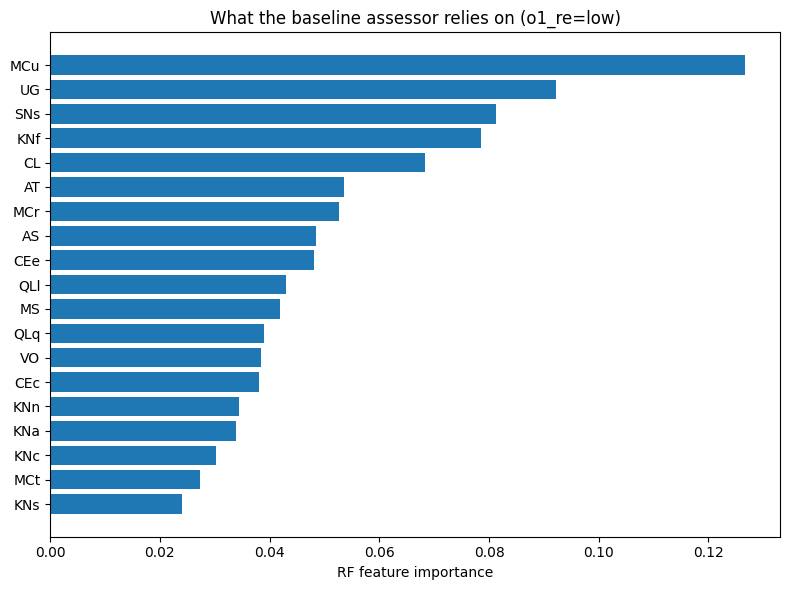

In [8]:
import matplotlib.pyplot as plt

# What is the baseline RF actually relying on? Single full-data fit on o1_re=low.
X = baseline_features(dfs['o1_re=low'])
y = dfs['o1_re=low']['verification_final']
keep = ~X.isna().any(axis=1)
m = default_rf(42).fit(X[keep], y[keep])
imp = pd.Series(m.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(imp.index, imp.values)
ax.set_xlabel('RF feature importance')
ax.set_title('What the baseline assessor relies on (o1_re=low)')
plt.tight_layout()
plt.show()

## 4. Your turn

You now have:

- `dfs['o1_re=low']` — the full DataFrame for the OpenAI o1 subject (all original columns, not just the 19 demands).
- `evaluate_all(feature_builder, model_factory=...)` — runs ID + OOD-task + OOD-benchmark and returns a comparison table.
- `baseline_features(df)` — the 19-feature paper baseline (use as reference).
- `default_rf(seed)` — the paper's Random Forest config (use as reference).

**Try to beat `baseline_table`** along *any* axis you find interesting (ID, OOD-task, OOD-benchmark; AUROC or ECE).

### 4a. Better features

Write a new `feature_builder(df) -> pd.DataFrame`. Pass it to `evaluate_all(your_features)` and compare to `baseline_table`.

In [ ]:
# Your code here.


### 4b. Better architecture

Write a new `model_factory(seed) -> classifier` (any object with `.fit(X, y)` and `.predict_proba(X)`). Pass it to `evaluate_all(baseline_features, model_factory=your_factory)`.

In [ ]:
# Your code here.


### 4c. Any other creative solutions that can improve explanatory power or predictive power

In [ ]:
# Your code here.